A. Load the dataset and report: Number of records, Number of features, Data types of all attributes 

In [31]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [32]:
# Load dataset

df = pd.read_csv("../data/housing.csv")
df.head()
# View first rows
df.head()
df_housing = pd.read_csv("../data/housing.csv")

In [33]:
# Report the basic structure of the dataset
print("Number of records:", df.shape[0])
print("Number of features (including target):", df.shape[1])
print("\nData types of all attributes:")
print(df.dtypes)

Number of records: 20640
Number of features (including target): 10

Data types of all attributes:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object


In [34]:
# Statistical summary (numerical)
df.describe()

# Categorical columns
df.select_dtypes(include=['object', 'string']).describe()

,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


In [35]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

B. Describe each attribute, explaining Its real-world meaning and whether it is numerical or categorical 

In [ ]:

# TASK B: DESCRIBE ATTRIBUTES

# Use housing dataset (unchanged)
numerical_cols = df_housing.select_dtypes(include=['number']).columns
print("Numerical Columns:\n", numerical_cols)

categorical_cols = df_housing.select_dtypes(include=['object', 'string']).columns
print("\nCategorical Columns:\n", categorical_cols)


# ---------- Attribute description table ----------
from tabulate import tabulate
import pandas as pd

attribute_data = {
    "Attribute": [
        "longitude",
        "latitude",
        "housing_median_age",
        "total_rooms",
        "total_bedrooms",
        "population",
        "households",
        "median_income",
        "median_house_value",
        "ocean_proximity"
    ],
    "Description": [
        "A measure of how far west a house block group is located; higher values are farther west",
        "A measure of how far north a house block group is located; higher values are farther north",
        "Median age in years of houses within a block group; lower values indicate newer buildings",
        "Total number of rooms across all houses within a block group",
        "Total number of bedrooms across all houses within a block group",
        "Total number of people residing within the block group",
        "Total number of households within a block group",
        "Median household income within the block group, measured in tens of thousands of USD",
        "Median monetary value in USD of all houses within the block group",
        "Location of the house with respect to the ocean or sea"
    ],
    "Real-World Meaning": [
        "Identifies the east–west geographic position of district block groups for spatial price analysis",
        "Identifies the north–south geographic position used to map housing patterns",
        "Describes whether neighborhoods are newly developed or long established",
        "Indicates housing size and density; meaningful when normalized by households",
        "Represents sleeping capacity of the housing stock",
        "Reflects settlement density and occupancy levels",
        "Used as a denominator for per-household feature engineering",
        "Strong indicator of socioeconomic status and housing demand",
        "Represents neighborhood-level housing affordability and market value",
        "Captures coastal proximity, a major driver of property prices in California"
    ],
    "Data Type": [
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Categorical"
    ]
}

df_attributes = pd.DataFrame(attribute_data)

print(tabulate(
    df_attributes,
    headers="keys",
    tablefmt="grid",
    showindex=False,
    colalign=("left", "left", "left", "center")
))


Numerical Columns:
 Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

Categorical Columns:
 Index(['ocean_proximity'], dtype='object')
+--------------------+--------------------------------------------------------------------------------------------+--------------------------------------------------------------------------------------------------+-------------+
| Attribute          | Description                                                                                | Real-World Meaning                                                                               |  Data Type  |
+====================+============================================================================================+==================================================================================================+=============+
| longitude          | A measure of 

C. Clearly define the regression target variable and The classification target variable 

In [37]:
#TASK C:DEFINE TARGET VARIABLES#

# Regression target
y_reg = df['median_house_value']

# Features
X = df.drop('median_house_value', axis=1)

print("Regression Target: median_house_value") 

Regression Target: median_house_value


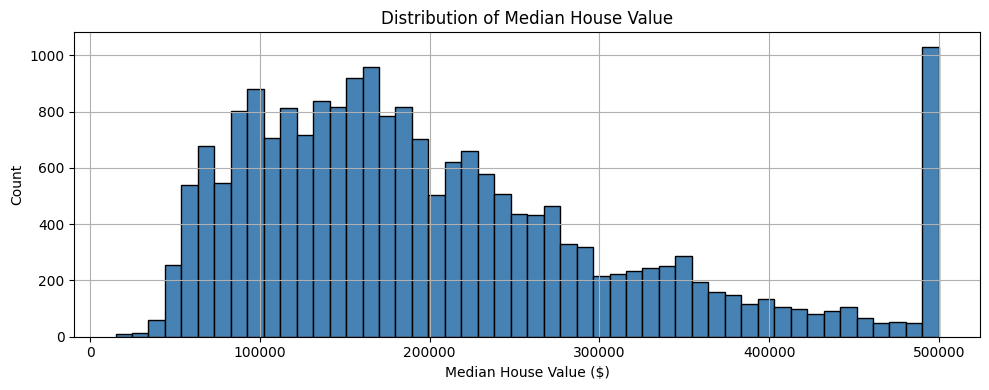

In [38]:
# Visualize house value distribution
plt.figure(figsize=(10, 4))
df['median_house_value'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

E.Explain how and why you transformed the continuous target into classes 

In [39]:
#TASK D:Transform Continuous Target into Classes#

# Create categories
df["price_category"] = pd.qcut(
    df["median_house_value"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

# Convert the categories to ordered numeric classes
# Adjusted approach to make the classes interpretable and avoid unnecessary label encoding ambiguity.
category_map = {"Low": 0, "Medium": 1, "High": 2}
df["price_category"] = df["price_category"].map(category_map).astype(int)

# Classification target
y_clf = df["price_category"]

print("Classification Target Created: price_category")
print(df["price_category"].value_counts().sort_index())

Classification Target Created: price_category
price_category
0    6884
1    6876
2    6880
Name: count, dtype: int64


The continuous target variable, `median_house_value`, was transformed into a **three-class categorical variable** using quantile-based discretization. Specifically, observations were partitioned into the lower, middle, and upper thirds of the price distribution and assigned the labels **Low**, **Medium**, and **High**, respectively.

This transformation is methodologically useful because it recasts a regression problem as a classification problem, thereby enabling the use of classifiers such as SVM. In addition, quantile-based binning promotes relatively balanced class sizes, which is beneficial for model training and evaluation. Although this approach reduces the precision of the original continuous outcome, it provides a more interpretable representation of housing affordability levels and supports multi-class predictive analysis.

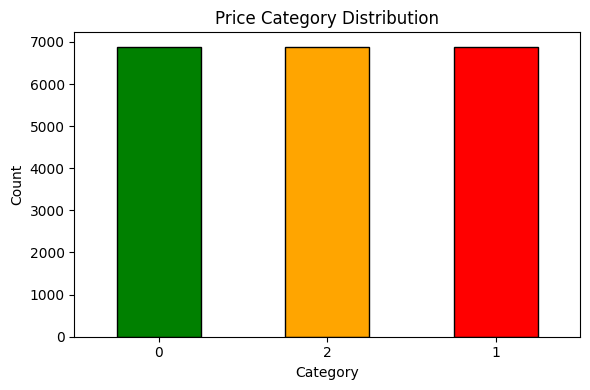

In [40]:
# Visualize class balance
df['price_category'].value_counts().plot(
    kind='bar', color=['green','orange','red'],
    edgecolor='black', figsize=(6,4)
)
plt.title('Price Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## TASK E: Model Selection Justification

## 1. Lasso Regression (Regression Task)

Lasso Regression was selected for the regression task because it is well-suited for predicting continuous variables such as median_house_value. One of its key advantages is its ability to perform feature selection by shrinking the coefficients of less important features to zero. This helps in identifying the most relevant predictors in the dataset.

Additionally, Lasso helps to reduce overfitting by applying regularization, which improves the model’s ability to generalize to unseen data. Since the housing dataset contains multiple features, Lasso Regression ensures a simpler and more interpretable model while maintaining good predictive performance.

## 2. Support Vector Machine (SVM) (Classification Task)

Support Vector Machine (SVM) was chosen for the classification task because it is highly effective in handling both linear and non-linear classification problems. In this case, the classification target (price_category) involves separating data into categories such as Low, Medium, and High.

SVM uses the concept of maximum margin separation, which helps to find the optimal boundary between classes. With the use of kernel functions such as the Radial Basis Function (RBF), SVM can model complex relationships in the data.

Furthermore, SVM performs well in high-dimensional spaces and is robust against overfitting, making it a suitable choice for classifying housing price categories.

## Summary
Lasso Regression was used for predicting continuous house prices due to its feature selection and regularization capabilities.
SVM was used for classification due to its ability to handle non-linear data and create optimal class boundaries.

The California Housing dataset contains 20,640 records, 8 input features, and one target variable, and the standard feature set is fully numerical except for the added ocean_proximity categorical field. The target is the median house value for each district, expressed in hundreds of thousands of dollars.

In [41]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,price_category
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,2
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,2
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,2
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,2
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,2


In [42]:
df.to_csv('../data/processed/california_housing_milestone1.csv', index=False)